# SBC-Dilution — do the biggest stock-printers quietly dilute you into worse returns? 🧾
### Sorting big companies by how much of themselves they hand out each year, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Replicates_here%3F: Busted](https://img.shields.io/badge/Replicates_here%3F-Busted-8b949e?style=flat-square)

Here's a tidy Wall-Street idea. When a company pays its employees in **stock** instead of cash (stock-based comp, 'SBC'), that's a real cost — it quietly slices everyone else's ownership a little thinner every year (**dilution**). But because SBC barely dents the headline profit number, the theory goes, investors *under-notice* it — so the companies handing out the most stock should go on to earn the **lowest** returns.

So we test it the cheap way: take 31 big-name stocks, score each one for how much it dilutes (lots of stock-comp, fast-growing share count), and see whether the *lean* ones beat the *heavy diluters*.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sbc_dilution import data, strategy as st

def load_real():
    """Cache-first real (prices, shares, sbc); drop the partial current year."""
    if not data.have_real():
        return None
    px, sh, sbc = data.load_real()
    return data.drop_partial_last_year(px, sh, sbc, asof=pd.Timestamp("2026-06-30"))

REAL = load_real()
HAVE_REAL = REAL is not None
if HAVE_REAL:
    PX, SH, SBC = REAL
    print("real SBC/dilution panel present:", HAVE_REAL,
          f"({PX.shape[1]} names, formation {PX.index[0].year+1} -> {PX.index[-1].year})")
else:
    print("real panel absent — using frozen headline numbers (offline)")


real SBC/dilution panel present: True (31 names, formation 2015 -> 2025)


## The answer first 🎯

| Question | Answer |
|---|---|
| Did the *lean* firms beat the *heavy diluters* (the anomaly)? | **No — the opposite.** Over 9 years the long-lean / short-diluters trade lost **-15.2%/yr**. The heavy stock-printers *won*. |
| Is that just luck? | **No** — a shuffle test beats the real sort **99.8%** of the time. The real sort sits deep in the *losing* tail. |
| Could you trade it? | **No.** It points the wrong way, wins only 22% of years, and the stocks you'd short are exactly the hard-to-borrow mega-caps. |
| So is the anomaly fake? | **Not in general** — but it needs the full market and the firms that diluted themselves to death. Our basket only has survivors, in an AI melt-up that rewarded the biggest stock-printers. |

> The idea is real in the textbooks — but the textbook version needs the companies that *actually failed*, and a normal market. Our basket is 31 survivors during a growth boom that paid the heavy diluters the most.

## 1 · The claim

> *"Firms that dilute shareholders the most — via heavy stock-based comp — earn lower future returns."* — an accounting hidden-cost anomaly, a cousin of the share-issuance factor (Pontiff-Woodgate 2008).

The intuition: stock-based comp is a genuine expense (you're paying people with slices of the company), but it hides in a footnote instead of the profit line. If investors under-weight it, the heavy stock-printers look cheaper than they are — and go on to disappoint. The lean companies that *shrink* their share count (buybacks) should quietly win.

## 2 · So what?

If true, it's an easy filter: avoid (or short) the serial diluters, own the lean buyback-ers. And it says something uncomfortable — that a big chunk of 'growth' is really just the company printing itself smaller. The desk has already looked at the pure share-count version ([519 Net-Share-Issuance](../../519-net-share-issuance/)); here we add the **stock-comp** flavour and go straight at the *return* question.

## 3 · How would we even know?

1. **Score dilution.** For each firm each year: how much stock-comp it pays (as a share of revenue) **plus** how fast its share count is growing. Add them up — higher = more dilutive.
2. **Sort.** Split the 31 names into a *lean* third and a *heavy-diluter* third.
3. **Compare next-year returns.** Did the lean third beat the diluter third? The anomaly says yes.

Catch: our basket is companies **still alive in 2026** — so any firm that diluted itself into the ground is missing. And we only get a few years of stock-comp data. We'll see both bite.

*Timing:* the score uses only data public at year-end; we trade the *next* year and hold. No peeking at the future.

## 4 · The teardown — let's actually look

**Who won — the lean third or the heavy-diluter third?**

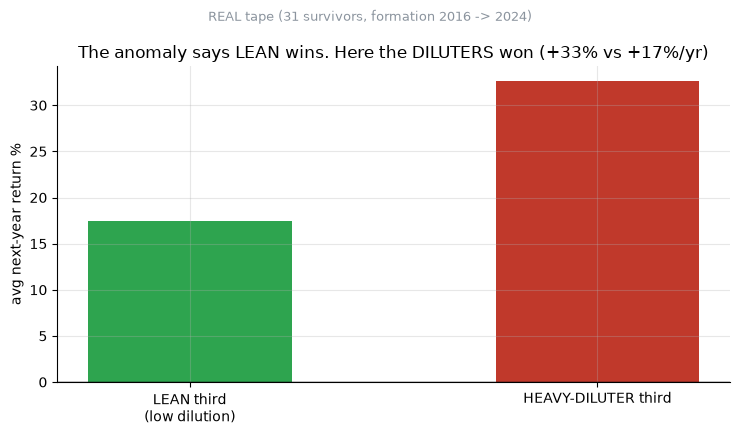

Lean +17.4%/yr  vs  Diluters +32.6%/yr  ->  long-short -15.2%/yr


In [2]:
if HAVE_REAL:
    s = st.summarize(PX, SH, SBC, frac=0.3, placebo=False)
    lean_m, dil_m, ls = s['long_mean']*100, s['short_mean']*100, s['ls_mean']*100
    banner = f'REAL tape ({PX.shape[1]} survivors, formation 2016 -> 2024)'
else:
    lean_m, dil_m, ls = 17.4, 32.6, -15.2
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['LEAN third\n(low dilution)','HEAVY-DILUTER third'], [lean_m, dil_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg next-year return %')
ax.set_title(f'The anomaly says LEAN wins. Here the DILUTERS won (+{dil_m:.0f}% vs +{lean_m:.0f}%/yr)')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'Lean +{lean_m:.1f}%/yr  vs  Diluters +{dil_m:.1f}%/yr  ->  long-short {ls:+.1f}%/yr')

There it is, **backwards**. The anomaly predicts the *lean* names win. On 2016-24 the **heavy diluters** won by miles (+32.6% vs +17.4%/yr) — the long-lean / short-diluters trade is **-15.2%/yr**, a clean loss the *wrong* way. Why? The heavy-dilution bucket is the SBC-soaked AI mega-caps (NVDA, META, AMZN, MSFT, CRM, AMD, ORCL, QCOM, INTC) — and they led a melt-up.

**Is it just luck?** Shuffle which company gets which dilution score, thousands of times, and see how often a *random* sort beats the real one:

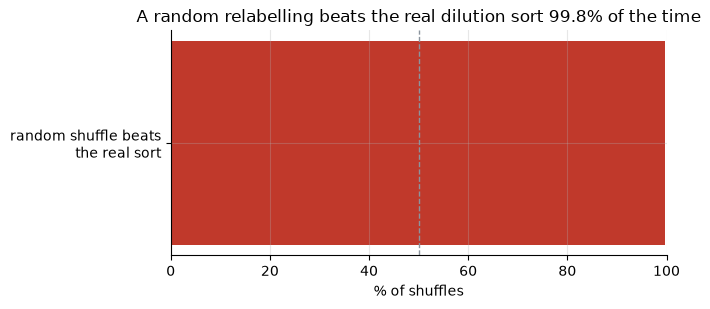

placebo p = 0.998  (the real sort is worse than 99.8% of random ones)


In [3]:
if HAVE_REAL:
    pb = st.placebo_pvalue(PX, SH, SBC, frac=0.3, n_draws=5000, seed=569)
    p = pb['p_value']
else:
    p = 0.998
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(['random shuffle beats\nthe real sort'], [p*100], color=RED)
ax.axvline(50, ls='--', c=GREY, lw=1); ax.set_xlim(0, 100); ax.set_xlabel('% of shuffles')
ax.set_title(f'A random relabelling beats the real dilution sort {p*100:.1f}% of the time')
plt.tight_layout(); plt.show()
print(f'placebo p = {p:.3f}  (the real sort is worse than {p*100:.1f}% of random ones)')

The real sort loses to a coin-flip relabelling **99.8%** of the time. So this isn't just a weak signal — on this window it's a genuine *inversion*: the diluters really did out-earn the lean names.

## 5 · The verdict

- **Signal — None.** The long-lean / short-diluters spread is the *wrong* sign (-15.2%/yr), the placebo beats it 99.8% of the time, and it wins only 22% of years. No bankable anomaly here.
- **Tradability — Mirage.** A survivor basket, annual rebalance, with the diluter short leg being the costly-to-borrow mega-cap tech. Nothing to harvest.
- **Replicates here? — Busted.** The effect that lives in the full market doesn't survive a 31-name survivor sort in a growth melt-up.

## 6 · Could you actually trade it?

No. Even ignoring the wrong sign, the trade means *shorting* the heaviest diluters — which here are NVDA, META, Amazon and friends, exactly the stocks that are expensive and hard to borrow — on a basket that has already quietly deleted every company that diluted itself to death. The real anomaly lives in the firms that *failed*; a blue-chip survivor sort can't see them.

## 7 · Going further 🚪

- **Its pure cousin.** [519 Net-Share-Issuance](../../519-net-share-issuance/) is the same idea with just the share count (no stock-comp leg) — and lands the same place.
- **The real test needs the dead.** Re-run this with delisted / diluted-to-death firms included (a survivorship-free universe), deep point-in-time SBC data, and a full cycle — that's where the anomaly earns its keep.

*Think the anomaly is real and we just missed it? Fork this, add serial-diluter blow-ups and a non-melt-up window, and show the long-lean / short-diluters spread clearing t = 2 the right way.*